# Options Pricing & Risk Analytics
### Black–Scholes–Merton • Binomial Trees • Monte Carlo • Implied Volatility • Greeks

**Objective.** Build an end-to-end derivatives analytics framework using real listed option-chain data. The notebook prices European options with three models, estimates implied volatility, analyzes Greeks and volatility skew, tests put–call parity, and compares theoretical values with observed market prices.

**Default underlying:** `SPY` (configurable)

> **Important:** This notebook does not fabricate market outputs. Run all cells with internet access to populate live option-chain results. Update the risk-free-rate input to a maturity-appropriate Treasury yield before treating outputs as final.

## 1. Imports & Configuration
The project uses only standard quantitative-finance/data libraries. Core pricing formulas are implemented manually rather than delegated to option-pricing packages.

In [1]:
!pip install -q yfinance

In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq
from sklearn.metrics import mean_absolute_error, mean_squared_error

import yfinance as yf

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ---------------- USER CONFIGURATION ----------------
TICKER = "SPY"
TARGET_DTE = 45                  # choose expiration nearest this many calendar days
RISK_FREE_RATE = 0.04            # update to maturity-matched Treasury yield before final run
DIVIDEND_YIELD_OVERRIDE = 0.0098   # e.g. 0.012; None = try Yahoo Finance, else default to 0
HIST_VOL_LOOKBACK = 252          # trading days
ATM_BAND = 0.02                  # +/- 2% around spot
STRIKES_EACH_SIDE = 8            # strikes around ATM for model comparison
MC_SIMULATIONS = 100_000
RANDOM_SEED = 42

## 2. Market Data Acquisition
The framework retrieves historical prices, the current spot price, available expirations, and call/put chains. Market option price is defined as the bid–ask midpoint when both quotes are usable; otherwise the last traded price is used as a fallback.

In [3]:
def get_market_data(symbol: str, period: str = "2y"):
    tk = yf.Ticker(symbol)
    hist = tk.history(period=period, auto_adjust=False)
    if hist.empty:
        raise ValueError(f"No historical data returned for {symbol}.")

    price_col = "Adj Close" if "Adj Close" in hist.columns else "Close"
    spot = float(hist[price_col].dropna().iloc[-1])

    expirations = list(tk.options)
    if not expirations:
        raise ValueError(f"No option expirations returned for {symbol}.")

    # Dividend yield: allow explicit override; otherwise try Yahoo metadata.
    if DIVIDEND_YIELD_OVERRIDE is not None:
        q = float(DIVIDEND_YIELD_OVERRIDE)
    else:
        try:
            info = tk.info
            q = info.get("dividendYield")
            q = float(q) if q is not None and np.isfinite(q) else 0.0
        except Exception:
            q = 0.0

    return tk, hist, spot, expirations, q


def choose_expiration(expirations, target_dte=45):
    today = pd.Timestamp.utcnow().tz_localize(None).normalize()
    parsed = pd.to_datetime(expirations)
    dtes = (parsed - today).days
    valid = [(e, int(d)) for e, d in zip(expirations, dtes) if d > 0]
    if not valid:
        raise ValueError("No future option expirations found.")
    return min(valid, key=lambda x: abs(x[1] - target_dte))


def clean_chain(df, option_type, spot):
    out = df.copy()
    out["option_type"] = option_type

    # Use bid/ask midpoint if both are positive; otherwise fall back to lastPrice.
    valid_quote = (out["bid"] > 0) & (out["ask"] > 0) & (out["ask"] >= out["bid"])
    out["market_price"] = np.where(
        valid_quote,
        (out["bid"] + out["ask"]) / 2,
        out["lastPrice"]
    )

    out["spread"] = out["ask"] - out["bid"]
    out["spread_pct"] = np.where(out["market_price"] > 0, out["spread"] / out["market_price"], np.nan)
    out["moneyness_ratio"] = out["strike"] / spot

    # Basic liquidity / validity screen.
    out = out[
        out["market_price"].notna()
        & (out["market_price"] > 0)
        & out["strike"].notna()
    ].copy()

    if "volume" in out.columns and "openInterest" in out.columns:
        liquid = (out["volume"].fillna(0) > 0) | (out["openInterest"].fillna(0) > 0)
        out = out[liquid].copy()

    return out.reset_index(drop=True)


ticker_obj, hist, spot, expirations, dividend_yield = get_market_data(TICKER)
expiration, dte = choose_expiration(expirations, TARGET_DTE)

chain = ticker_obj.option_chain(expiration)
calls = clean_chain(chain.calls, "call", spot)
puts  = clean_chain(chain.puts, "put", spot)

valuation_date = pd.Timestamp.utcnow().tz_localize(None).normalize()
expiry_date = pd.Timestamp(expiration)
T = max((expiry_date - valuation_date).days / 365.0, 1 / 365)

print(f"Underlying:       {TICKER}")
print(f"Spot price:       ${spot:,.2f}")
print(f"Expiration:       {expiration}")
print(f"Calendar DTE:     {dte}")
print(f"Year fraction:    {T:.4f}")
print(f"Risk-free rate:   {RISK_FREE_RATE:.2%}")
print(f"Dividend yield:   {dividend_yield:.2%}")
print(f"Calls retained:   {len(calls)}")
print(f"Puts retained:    {len(puts)}")

Underlying:       SPY
Spot price:       $763.00
Expiration:       2026-10-23
Calendar DTE:     44
Year fraction:    0.1205
Risk-free rate:   4.00%
Dividend yield:   0.98%
Calls retained:   83
Puts retained:    94


## 3. Historical Volatility
Historical volatility is estimated from daily log returns and annualized with \(\sqrt{252}\). It is used as a common ex-ante volatility input when comparing BSM, binomial and Monte Carlo prices with observed market prices. This avoids the circular exercise of using each option's implied volatility to reproduce its own market price.

252-day annualized historical volatility: 12.81%


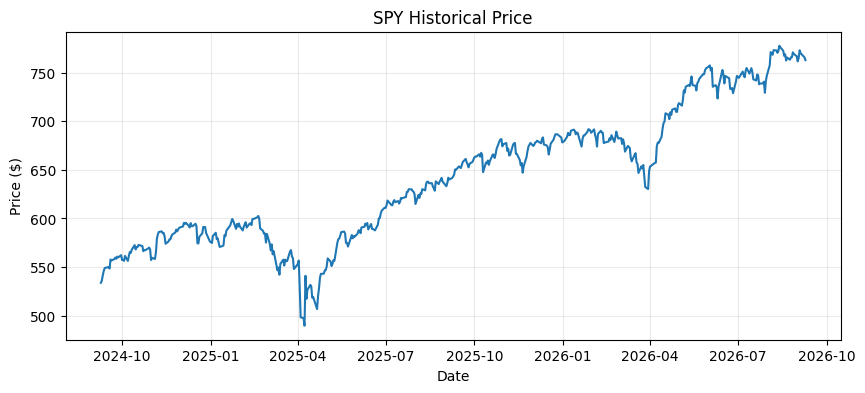

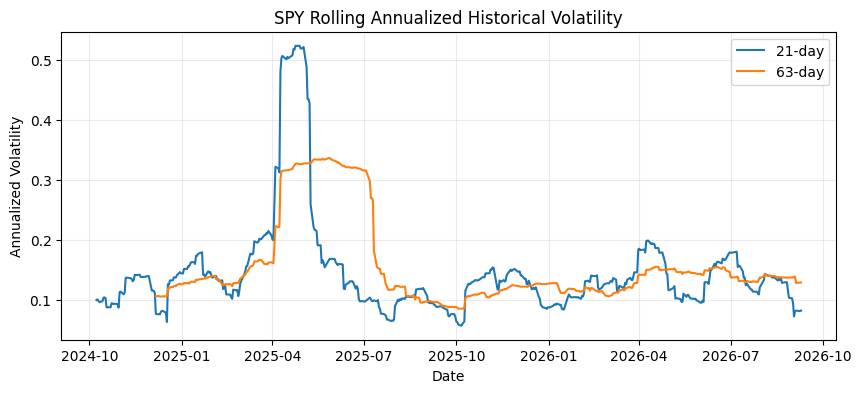

In [4]:
price_col = "Adj Close" if "Adj Close" in hist.columns else "Close"
prices = hist[price_col].dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

historical_vol = float(log_returns.tail(HIST_VOL_LOOKBACK).std(ddof=1) * np.sqrt(252))
rolling_vol_21 = log_returns.rolling(21).std() * np.sqrt(252)
rolling_vol_63 = log_returns.rolling(63).std() * np.sqrt(252)

print(f"{HIST_VOL_LOOKBACK}-day annualized historical volatility: {historical_vol:.2%}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(prices.index, prices.values)
ax.set_title(f"{TICKER} Historical Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rolling_vol_21.index, rolling_vol_21.values, label="21-day")
ax.plot(rolling_vol_63.index, rolling_vol_63.values, label="63-day")
ax.set_title(f"{TICKER} Rolling Annualized Historical Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 4. Black–Scholes–Merton Pricing
For continuous dividend yield \(q\):

\[
d_1=\frac{\ln(S/K)+(r-q+\sigma^2/2)T}{\sigma\sqrt{T}},
\qquad
d_2=d_1-\sigma\sqrt{T}
\]

\[
C=Se^{-qT}N(d_1)-Ke^{-rT}N(d_2)
\]

\[
P=Ke^{-rT}N(-d_2)-Se^{-qT}N(-d_1)
\]

In [5]:
def _validate_inputs(S, K, T, sigma):
    if S <= 0 or K <= 0:
        raise ValueError("S and K must be positive.")
    if T <= 0:
        raise ValueError("T must be positive.")
    if sigma <= 0:
        raise ValueError("sigma must be positive.")


def _d1_d2(S, K, T, r, sigma, q=0.0):
    _validate_inputs(S, K, T, sigma)
    sqrtT = math.sqrt(T)
    d1 = (math.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2


def black_scholes_price(S, K, T, r, sigma, q=0.0, option_type="call"):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    disc_q = math.exp(-q * T)
    disc_r = math.exp(-r * T)

    if option_type.lower() == "call":
        return S * disc_q * norm.cdf(d1) - K * disc_r * norm.cdf(d2)
    elif option_type.lower() == "put":
        return K * disc_r * norm.cdf(-d2) - S * disc_q * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'.")


# Quick sanity check
example_call = black_scholes_price(100, 100, 1, 0.05, 0.20, 0.0, "call")
example_put  = black_scholes_price(100, 100, 1, 0.05, 0.20, 0.0, "put")
print(f"Sanity-check call: {example_call:.4f}")
print(f"Sanity-check put:  {example_put:.4f}")

Sanity-check call: 10.4506
Sanity-check put:  5.5735


## 5. Greeks & Risk Analysis
Greeks quantify local option-price sensitivity to the major risk drivers. Vega and rho below are reported **per 1 percentage-point change** in volatility and rates; theta is reported **per calendar day**.

In [6]:
def calculate_greeks(S, K, T, r, sigma, q=0.0, option_type="call"):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    disc_q = math.exp(-q * T)
    disc_r = math.exp(-r * T)
    pdf_d1 = norm.pdf(d1)

    gamma = disc_q * pdf_d1 / (S * sigma * math.sqrt(T))
    vega_per_1pct = S * disc_q * pdf_d1 * math.sqrt(T) / 100

    if option_type.lower() == "call":
        delta = disc_q * norm.cdf(d1)
        theta_annual = (
            -(S * disc_q * pdf_d1 * sigma) / (2 * math.sqrt(T))
            - r * K * disc_r * norm.cdf(d2)
            + q * S * disc_q * norm.cdf(d1)
        )
        rho_per_1pct = K * T * disc_r * norm.cdf(d2) / 100
    elif option_type.lower() == "put":
        delta = disc_q * (norm.cdf(d1) - 1)
        theta_annual = (
            -(S * disc_q * pdf_d1 * sigma) / (2 * math.sqrt(T))
            + r * K * disc_r * norm.cdf(-d2)
            - q * S * disc_q * norm.cdf(-d1)
        )
        rho_per_1pct = -K * T * disc_r * norm.cdf(-d2) / 100
    else:
        raise ValueError("option_type must be 'call' or 'put'.")

    return {
        "delta": delta,
        "gamma": gamma,
        "vega_1pct": vega_per_1pct,
        "theta_day": theta_annual / 365,
        "rho_1pct": rho_per_1pct,
    }

## 6. Implied Volatility
Implied volatility is solved independently from the observed option price using Brent's root-finding method. No-arbitrage price bounds are checked before attempting the solve.

In [7]:
def no_arbitrage_bounds(S, K, T, r, q=0.0, option_type="call"):
    pvS = S * math.exp(-q * T)
    pvK = K * math.exp(-r * T)
    if option_type == "call":
        return max(0.0, pvS - pvK), pvS
    else:
        return max(0.0, pvK - pvS), pvK


def implied_volatility(market_price, S, K, T, r, q=0.0, option_type="call",
                       sigma_low=1e-6, sigma_high=5.0):
    if not np.isfinite(market_price) or market_price <= 0:
        return np.nan

    lower, upper = no_arbitrage_bounds(S, K, T, r, q, option_type)
    if market_price < lower - 1e-8 or market_price > upper + 1e-8:
        return np.nan

    def objective(sigma):
        return black_scholes_price(S, K, T, r, sigma, q, option_type) - market_price

    try:
        return brentq(objective, sigma_low, sigma_high, maxiter=200, xtol=1e-10)
    except (ValueError, RuntimeError):
        return np.nan


for df in (calls, puts):
    df["calc_iv"] = df.apply(
        lambda row: implied_volatility(
            row["market_price"], spot, row["strike"], T,
            RISK_FREE_RATE, dividend_yield, row["option_type"]
        ),
        axis=1
    )

# Keep economically plausible solved IVs for analysis.
calls_iv = calls[calls["calc_iv"].between(0.01, 3.0)].copy()
puts_iv  = puts[puts["calc_iv"].between(0.01, 3.0)].copy()

print("Solved call IVs:", len(calls_iv))
print("Solved put IVs: ", len(puts_iv))

Solved call IVs: 83
Solved put IVs:  94


## 7. Volatility Smile / Skew
A constant-volatility BSM model cannot reproduce the strike-dependent implied volatilities observed in real markets. Equity and index options often exhibit downside skew, with lower-strike puts carrying higher implied volatility.

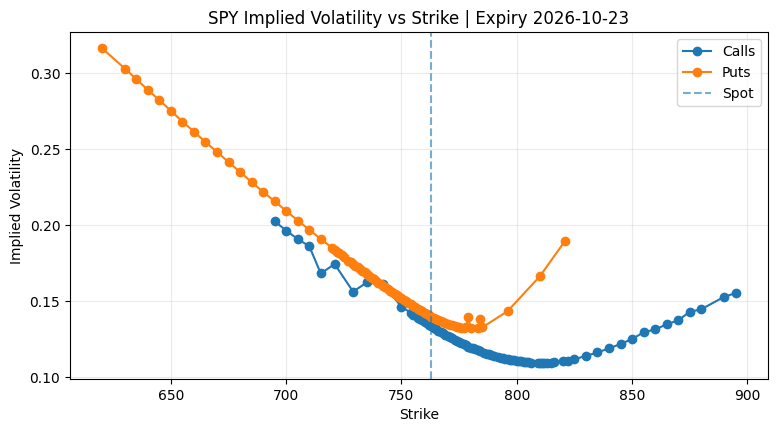

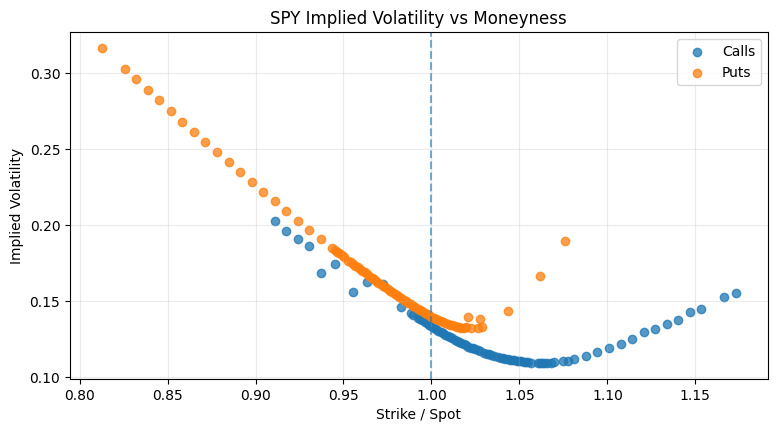

Median |calculated IV - reported IV|: 0.6844%


In [8]:
def trim_by_moneyness(df, low=0.80, high=1.20):
    return df[df["moneyness_ratio"].between(low, high)].sort_values("strike").copy()

calls_plot = trim_by_moneyness(calls_iv)
puts_plot = trim_by_moneyness(puts_iv)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(calls_plot["strike"], calls_plot["calc_iv"], marker="o", label="Calls")
ax.plot(puts_plot["strike"], puts_plot["calc_iv"], marker="o", label="Puts")
ax.axvline(spot, linestyle="--", alpha=0.6, label="Spot")
ax.set_title(f"{TICKER} Implied Volatility vs Strike | Expiry {expiration}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(calls_plot["moneyness_ratio"], calls_plot["calc_iv"], label="Calls", alpha=0.75)
ax.scatter(puts_plot["moneyness_ratio"], puts_plot["calc_iv"], label="Puts", alpha=0.75)
ax.axvline(1.0, linestyle="--", alpha=0.6)
ax.set_title(f"{TICKER} Implied Volatility vs Moneyness")
ax.set_xlabel("Strike / Spot")
ax.set_ylabel("Implied Volatility")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

if "impliedVolatility" in calls_iv.columns:
    iv_compare = calls_iv[["strike", "calc_iv", "impliedVolatility"]].dropna().copy()
    iv_compare["iv_diff"] = iv_compare["calc_iv"] - iv_compare["impliedVolatility"]
    print("Median |calculated IV - reported IV|:",
          f"{iv_compare['iv_diff'].abs().median():.4%}")

## 8. Binomial Tree Pricing
The Cox–Ross–Rubinstein tree is implemented manually. For European options, the price should converge toward BSM as the number of steps increases. The same framework can also accommodate American early exercise.

,steps,binomial_price,abs_error_vs_bsm
0,10,14.5902,0.3337
1,25,15.0581,0.1342
2,50,14.8564,0.0675
3,100,14.8901,0.0338
4,250,14.9104,0.0135
5,500,14.9172,0.0068


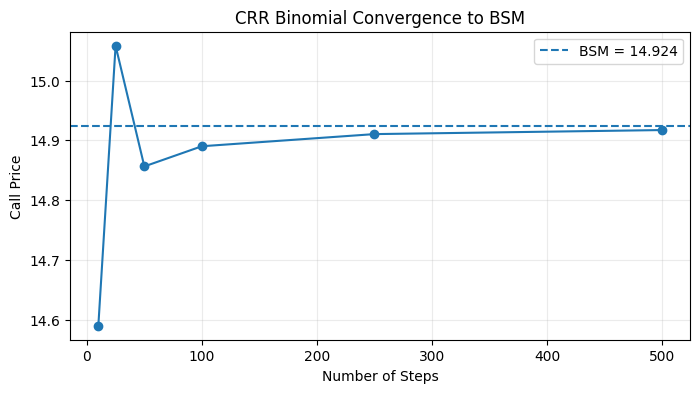

In [9]:
def binomial_price(S, K, T, r, sigma, q=0.0, option_type="call",
                   steps=200, american=False):
    _validate_inputs(S, K, T, sigma)
    if steps < 1:
        raise ValueError("steps must be >= 1.")

    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    growth = math.exp((r - q) * dt)
    p = (growth - d) / (u - d)

    if not (0 <= p <= 1):
        return np.nan

    disc = math.exp(-r * dt)
    j = np.arange(steps + 1)
    ST = S * (u ** j) * (d ** (steps - j))

    if option_type == "call":
        values = np.maximum(ST - K, 0.0)
    else:
        values = np.maximum(K - ST, 0.0)

    for i in range(steps - 1, -1, -1):
        values = disc * (p * values[1:i+2] + (1-p) * values[0:i+1])

        if american:
            j = np.arange(i + 1)
            Si = S * (u ** j) * (d ** (i - j))
            exercise = np.maximum(Si - K, 0.0) if option_type == "call" else np.maximum(K - Si, 0.0)
            values = np.maximum(values, exercise)

    return float(values[0])


atm_strike = float(calls.iloc[(calls["strike"] - spot).abs().argsort()[:1]]["strike"].iloc[0])
step_grid = [10, 25, 50, 100, 250, 500]
bsm_atm = black_scholes_price(
    spot, atm_strike, T, RISK_FREE_RATE, historical_vol, dividend_yield, "call"
)

binomial_convergence = pd.DataFrame({
    "steps": step_grid,
    "binomial_price": [
        binomial_price(spot, atm_strike, T, RISK_FREE_RATE, historical_vol,
                       dividend_yield, "call", steps=n)
        for n in step_grid
    ]
})
binomial_convergence["abs_error_vs_bsm"] = (
    binomial_convergence["binomial_price"] - bsm_atm
).abs()

display(binomial_convergence)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(binomial_convergence["steps"], binomial_convergence["binomial_price"], marker="o")
ax.axhline(bsm_atm, linestyle="--", label=f"BSM = {bsm_atm:.3f}")
ax.set_title("CRR Binomial Convergence to BSM")
ax.set_xlabel("Number of Steps")
ax.set_ylabel("Call Price")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 9. Monte Carlo Pricing
Under risk-neutral geometric Brownian motion:

\[
S_T=S_0\exp\left[\left(r-q-
rac{\sigma^2}{2}
ight)T+\sigma\sqrt{T}Z
ight]
\]

The discounted expected payoff estimates the European option value. The implementation returns a standard error and 95% confidence interval.

In [10]:
def monte_carlo_price(S, K, T, r, sigma, q=0.0, option_type="call",
                      simulations=100_000, seed=42, antithetic=True):
    _validate_inputs(S, K, T, sigma)
    rng = np.random.default_rng(seed)

    if antithetic:
        n_pairs = simulations // 2
        z = rng.standard_normal(n_pairs)

        ST_plus = S * np.exp(
            (r - q - 0.5 * sigma**2) * T
            + sigma * math.sqrt(T) * z
        )

        ST_minus = S * np.exp(
            (r - q - 0.5 * sigma**2) * T
            - sigma * math.sqrt(T) * z
        )

        if option_type == "call":
            payoff_plus = np.maximum(ST_plus - K, 0.0)
            payoff_minus = np.maximum(ST_minus - K, 0.0)
        else:
            payoff_plus = np.maximum(K - ST_plus, 0.0)
            payoff_minus = np.maximum(K - ST_minus, 0.0)

        # Each antithetic pair is one independent observation
        discounted_pairs = math.exp(-r * T) * (
            payoff_plus + payoff_minus
        ) / 2

        price = float(discounted_pairs.mean())
        se = float(
            discounted_pairs.std(ddof=1) /
            math.sqrt(len(discounted_pairs))
        )

    else:
        z = rng.standard_normal(simulations)

        ST = S * np.exp(
            (r - q - 0.5 * sigma**2) * T
            + sigma * math.sqrt(T) * z
        )

        payoff = (
            np.maximum(ST - K, 0.0)
            if option_type == "call"
            else np.maximum(K - ST, 0.0)
        )

        discounted = math.exp(-r * T) * payoff

        price = float(discounted.mean())
        se = float(
            discounted.std(ddof=1) /
            math.sqrt(len(discounted))
        )

    ci = (
        price - 1.96 * se,
        price + 1.96 * se
    )

    return {
        "price": price,
        "std_error": se,
        "ci_low": ci[0],
        "ci_high": ci[1],
    }

## 10. Market vs Model Comparison
For a selected band of liquid strikes around ATM, the same historical-volatility input is used across BSM, binomial and Monte Carlo. This isolates differences in model mechanics from differences caused by using strike-specific implied volatilities.

BSM MAE:  $0.6119
BSM RMSE: $0.7538


,strike,moneyness,market_price,bsm_price,binomial_price,monte_carlo_price,implied_vol,bsm_abs_error,bsm_pct_error
0,754.0000,ATM,21.5100,20.0849,20.0922,20.1090,0.1424,1.4251,0.0663
1,755.0000,ATM,20.7850,19.4656,19.4591,19.4890,0.1413,1.3194,0.0635
2,757.0000,ATM,19.3650,18.2610,18.2717,18.2826,0.1389,1.1040,0.0570
3,758.0000,ATM,18.7300,17.6759,17.6824,17.6971,0.1384,1.0541,0.0563
4,759.0000,ATM,18.0700,17.1023,17.0932,17.1230,0.1375,0.9677,0.0536
5,760.0000,ATM,17.4100,16.5402,16.5450,16.5603,0.1365,0.8698,0.0500
6,761.0000,ATM,16.7600,15.9898,16.0009,16.0088,0.1355,0.7702,0.0460
7,762.0000,ATM,16.1050,15.4510,15.4568,15.4688,0.1343,0.6540,0.0406
8,763.0000,ATM,15.4900,14.9240,14.9127,14.9406,0.1335,0.5660,0.0365
9,764.0000,ATM,14.8800,14.4085,14.4143,14.4244,0.1326,0.4715,0.0317


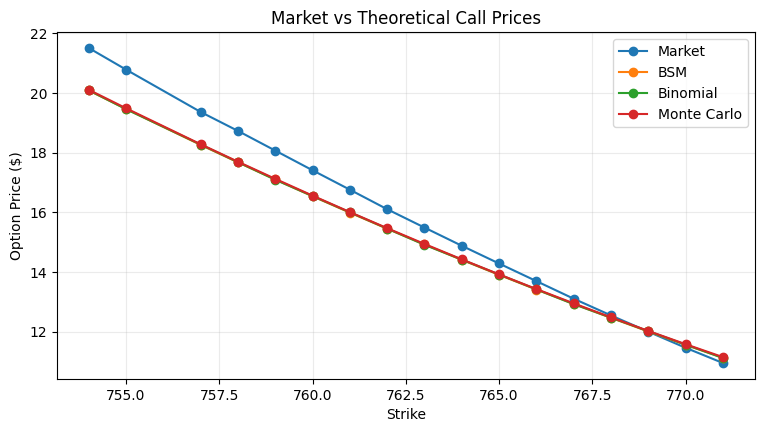

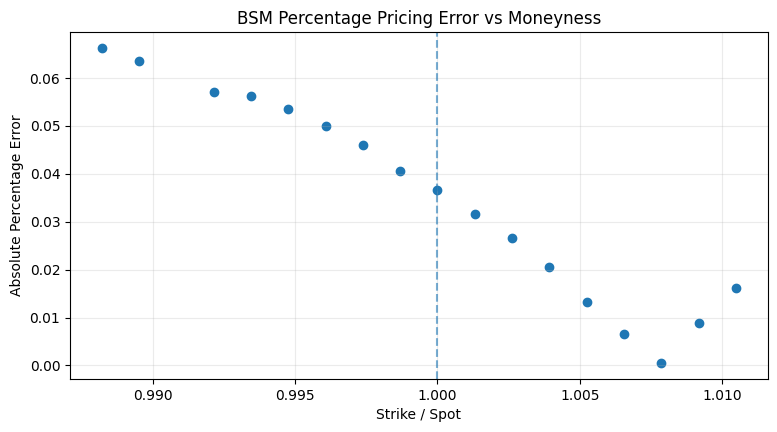

,count,mean,median
moneyness,,,
ATM,17,0.6119,0.5660


In [11]:
def classify_moneyness(K, S, option_type, band=0.02):
    ratio = K / S
    if abs(ratio - 1) <= band:
        return "ATM"
    if option_type == "call":
        return "ITM" if K < S else "OTM"
    else:
        return "ITM" if K > S else "OTM"


def select_near_atm(df, spot, each_side=8):
    tmp = df.sort_values("strike").copy()
    idx = int(np.argmin(np.abs(tmp["strike"].values - spot)))
    lo = max(0, idx - each_side)
    hi = min(len(tmp), idx + each_side + 1)
    return tmp.iloc[lo:hi].copy()


comparison_source = select_near_atm(calls, spot, STRIKES_EACH_SIDE)
rows = []

for _, row in comparison_source.iterrows():
    K = float(row["strike"])
    market = float(row["market_price"])

    bsm = black_scholes_price(
        spot, K, T, RISK_FREE_RATE, historical_vol, dividend_yield, "call"
    )
    bino = binomial_price(
        spot, K, T, RISK_FREE_RATE, historical_vol, dividend_yield,
        "call", steps=300
    )
    mc = monte_carlo_price(
        spot, K, T, RISK_FREE_RATE, historical_vol, dividend_yield,
        "call", simulations=MC_SIMULATIONS, seed=RANDOM_SEED
    )["price"]

    iv = implied_volatility(
        market, spot, K, T, RISK_FREE_RATE, dividend_yield, "call"
    )

    rows.append({
        "strike": K,
        "moneyness": classify_moneyness(K, spot, "call", ATM_BAND),
        "market_price": market,
        "bsm_price": bsm,
        "binomial_price": bino,
        "monte_carlo_price": mc,
        "implied_vol": iv,
        "bsm_abs_error": abs(bsm - market),
        "bsm_pct_error": abs(bsm - market) / market if market > 0 else np.nan,
    })

comparison = pd.DataFrame(rows).sort_values("strike").reset_index(drop=True)

mae = mean_absolute_error(comparison["market_price"], comparison["bsm_price"])
rmse = mean_squared_error(
    comparison["market_price"], comparison["bsm_price"]
) ** 0.5

print(f"BSM MAE:  ${mae:.4f}")
print(f"BSM RMSE: ${rmse:.4f}")
display(comparison)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(comparison["strike"], comparison["market_price"], marker="o", label="Market")
ax.plot(comparison["strike"], comparison["bsm_price"], marker="o", label="BSM")
ax.plot(comparison["strike"], comparison["binomial_price"], marker="o", label="Binomial")
ax.plot(comparison["strike"], comparison["monte_carlo_price"], marker="o", label="Monte Carlo")
ax.set_title("Market vs Theoretical Call Prices")
ax.set_xlabel("Strike")
ax.set_ylabel("Option Price ($)")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(comparison["strike"] / spot, comparison["bsm_pct_error"])
ax.axvline(1.0, linestyle="--", alpha=0.6)
ax.set_title("BSM Percentage Pricing Error vs Moneyness")
ax.set_xlabel("Strike / Spot")
ax.set_ylabel("Absolute Percentage Error")
ax.grid(alpha=0.25)
plt.show()

moneyness_error = comparison.groupby("moneyness")["bsm_abs_error"].agg(["count", "mean", "median"])
display(moneyness_error)

## 11. Put–Call Parity Benchmark

Matched call and put contracts are compared with the European put–call parity relationship:

C - P = S e^(-qT) - K e^(-rT)

SPY options are American-style, while this relationship assumes European exercise.
Therefore, the analysis is used as a theoretical benchmark rather than a strict
arbitrage test. Deviations may also reflect bid–ask spreads, stale quotes,
liquidity, dividends and early-exercise effects.

,strike,call_price,put_price,lhs,rhs,parity_deviation
0,695.0000,72.4000,2.5000,69.9000,70.4423,-0.5423
1,700.0000,67.6500,2.7600,64.8900,65.4664,-0.5764
2,705.0000,62.9500,3.0550,59.8950,60.4904,-0.5954
3,710.0000,58.3450,3.4050,54.9400,55.5145,-0.5745
4,715.0000,53.0800,3.8000,49.2800,50.5385,-1.2585
5,721.0000,48.3350,4.3800,43.9550,44.5674,-0.6124
6,729.0000,40.6100,5.3050,35.3050,36.6059,-1.3009
7,735.0000,36.3700,6.1750,30.1950,30.6347,-0.4397
8,742.0000,31.1700,7.4200,23.7500,23.6684,0.0816
9,750.0000,24.4150,9.2350,15.1800,15.7069,-0.5269


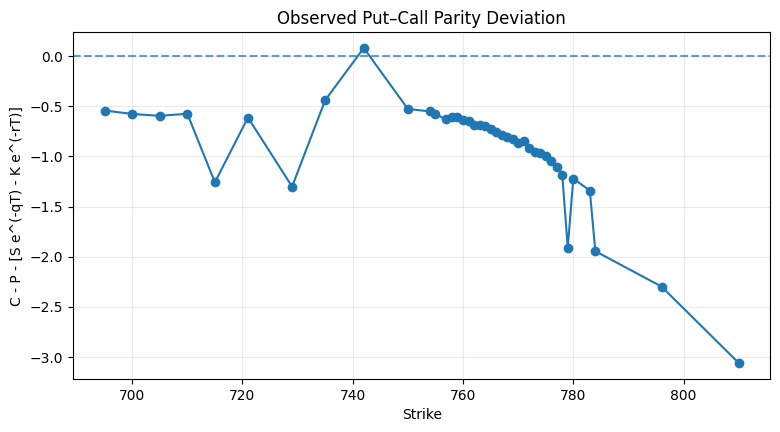

In [12]:
parity = calls[["strike", "market_price", "bid", "ask"]].rename(
    columns={"market_price": "call_price", "bid": "call_bid", "ask": "call_ask"}
).merge(
    puts[["strike", "market_price", "bid", "ask"]].rename(
        columns={"market_price": "put_price", "bid": "put_bid", "ask": "put_ask"}
    ),
    on="strike",
    how="inner"
)

parity["lhs"] = parity["call_price"] - parity["put_price"]
parity["rhs"] = (
    spot * math.exp(-dividend_yield * T)
    - parity["strike"] * math.exp(-RISK_FREE_RATE * T)
)
parity["parity_deviation"] = parity["lhs"] - parity["rhs"]
parity["abs_deviation"] = parity["parity_deviation"].abs()

parity_near = parity[
    parity["strike"].between(0.85 * spot, 1.15 * spot)
].sort_values("strike").copy()

display(parity_near[[
    "strike", "call_price", "put_price", "lhs", "rhs", "parity_deviation"
]])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(parity_near["strike"], parity_near["parity_deviation"], marker="o")
ax.axhline(0, linestyle="--", alpha=0.7)
ax.set_title("Observed Put–Call Parity Deviation")
ax.set_xlabel("Strike")
ax.set_ylabel("C - P - [S e^(-qT) - K e^(-rT)]")
ax.grid(alpha=0.25)
plt.show()

## 12. Sensitivity & Scenario Analysis
The sensitivity section maps option value across underlying price and volatility and illustrates how the core risk drivers interact.

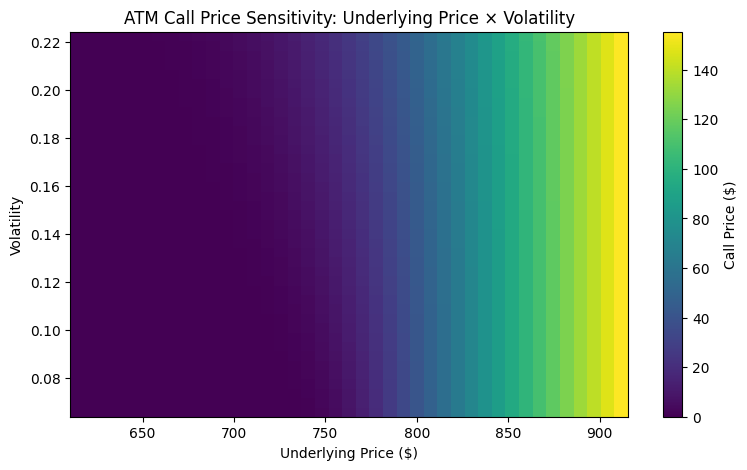

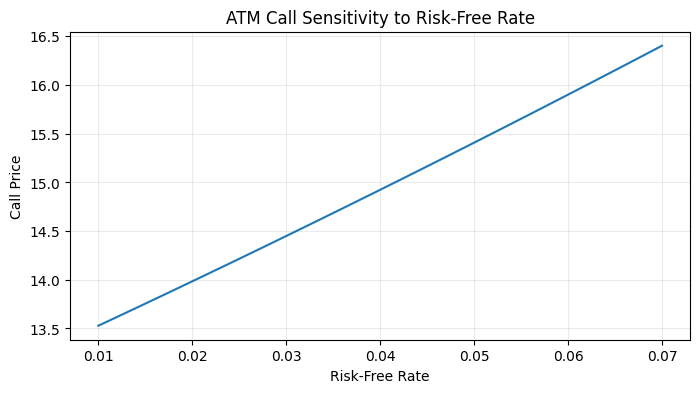

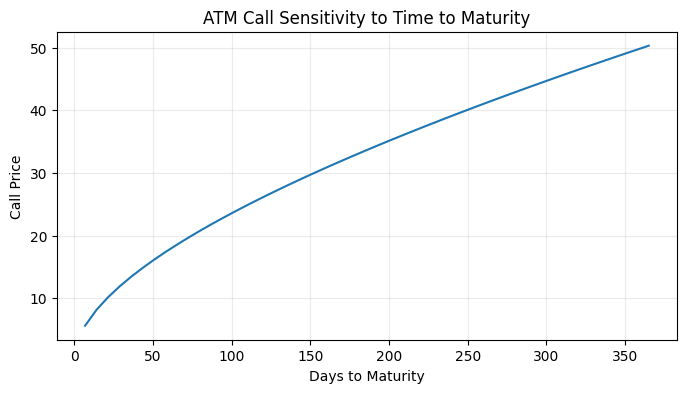

In [13]:
S_grid = np.linspace(0.80 * spot, 1.20 * spot, 41)
vol_grid = np.linspace(max(0.05, 0.50 * historical_vol), 1.75 * historical_vol, 41)

heat = np.empty((len(vol_grid), len(S_grid)))
for i, vol in enumerate(vol_grid):
    for j, S_ in enumerate(S_grid):
        heat[i, j] = black_scholes_price(
            S_, atm_strike, T, RISK_FREE_RATE, vol, dividend_yield, "call"
        )

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(
    heat,
    origin="lower",
    aspect="auto",
    extent=[S_grid.min(), S_grid.max(), vol_grid.min(), vol_grid.max()]
)
ax.set_title("ATM Call Price Sensitivity: Underlying Price × Volatility")
ax.set_xlabel("Underlying Price ($)")
ax.set_ylabel("Volatility")
fig.colorbar(im, ax=ax, label="Call Price ($)")
plt.show()

# One-dimensional sensitivities
rate_grid = np.linspace(max(-0.01, RISK_FREE_RATE - 0.03), RISK_FREE_RATE + 0.03, 40)
time_grid = np.linspace(7/365, 365/365, 50)

rate_prices = [
    black_scholes_price(spot, atm_strike, T, r_, historical_vol, dividend_yield, "call")
    for r_ in rate_grid
]
time_prices = [
    black_scholes_price(spot, atm_strike, t_, RISK_FREE_RATE, historical_vol, dividend_yield, "call")
    for t_ in time_grid
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rate_grid, rate_prices)
ax.set_title("ATM Call Sensitivity to Risk-Free Rate")
ax.set_xlabel("Risk-Free Rate")
ax.set_ylabel("Call Price")
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_grid * 365, time_prices)
ax.set_title("ATM Call Sensitivity to Time to Maturity")
ax.set_xlabel("Days to Maturity")
ax.set_ylabel("Call Price")
ax.grid(alpha=0.25)
plt.show()

## 13. Greeks Across Strike
For the Greek surface, solved implied volatility is used contract-by-contract where available. This reflects the market's volatility structure rather than forcing a flat volatility assumption.

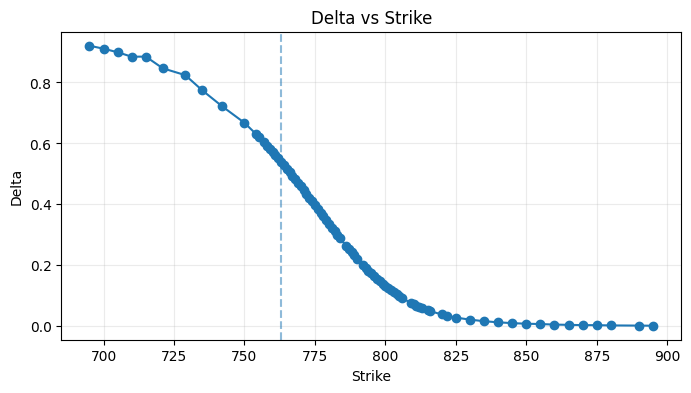

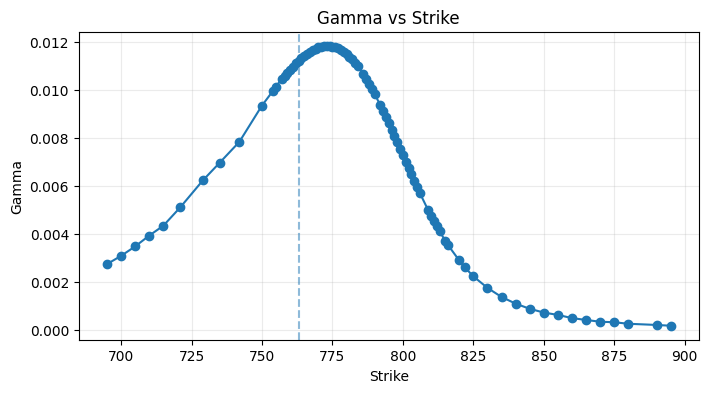

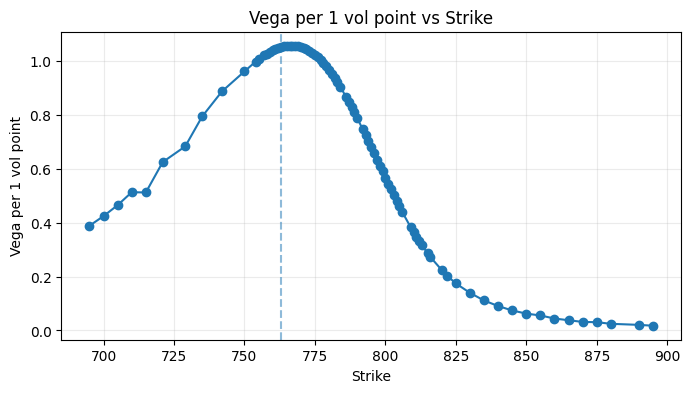

In [14]:
greeks_df = trim_by_moneyness(calls_iv).copy()

def row_greeks(row):
    g = calculate_greeks(
        spot, float(row["strike"]), T, RISK_FREE_RATE,
        float(row["calc_iv"]), dividend_yield, "call"
    )
    return pd.Series(g)

greeks_values = greeks_df.apply(row_greeks, axis=1)
greeks_df = pd.concat([greeks_df.reset_index(drop=True), greeks_values.reset_index(drop=True)], axis=1)

for greek, ylabel in [
    ("delta", "Delta"),
    ("gamma", "Gamma"),
    ("vega_1pct", "Vega per 1 vol point"),
]:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(greeks_df["strike"], greeks_df[greek], marker="o")
    ax.axvline(spot, linestyle="--", alpha=0.5)
    ax.set_title(f"{ylabel} vs Strike")
    ax.set_xlabel("Strike")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    plt.show()

## 14. Key Findings
This cell generates a concise executive summary from the calculated outputs rather than hard-coding a predetermined conclusion.

In [15]:
summary_lines = []

# Model comparison
summary_lines.append(
    f"BSM, Binomial and Monte Carlo prices were compared using the same "
    f"historical-volatility assumption; differences between the three "
    f"theoretical models were small relative to deviations from observed "
    f"market prices."
)

# IV vs historical vol
median_call_iv = calls_iv["calc_iv"].median()
if np.isfinite(median_call_iv):
    relation = "above" if median_call_iv > historical_vol else "below"
    summary_lines.append(
        f"Median solved call implied volatility ({median_call_iv:.2%}) was {relation} "
        f"the {HIST_VOL_LOOKBACK}-day historical volatility estimate ({historical_vol:.2%})."
    )

# Skew
if len(puts_plot) >= 4:
    low = puts_plot.nsmallest(max(2, len(puts_plot)//4), "strike")["calc_iv"].median()
    high = puts_plot.nlargest(max(2, len(puts_plot)//4), "strike")["calc_iv"].median()
    if np.isfinite(low) and np.isfinite(high):
        if low > high:
            summary_lines.append(
                "Lower-strike puts carried higher implied volatility than higher-strike puts, "
                "consistent with downside volatility skew."
            )
        else:
            summary_lines.append(
                "The selected put chain did not display a conventional monotonic downside skew "
                "over the filtered strike range."
            )

# Moneyness error
if not moneyness_error.empty:
    worst_bucket = moneyness_error["mean"].idxmax()
    summary_lines.append(
        f"The highest average BSM absolute error occurred in the {worst_bucket} bucket "
        "for the selected option set."
    )

# Parity
if len(parity_near):
    summary_lines.append(
        f"Median absolute put-call parity deviation across near-the-money matched contracts was "
        f"${parity_near['abs_deviation'].median():.4f}."
    )

print("\nKEY FINDINGS")
print("-" * 70)
for s in summary_lines:
    print("•", s)


KEY FINDINGS
----------------------------------------------------------------------
• BSM, Binomial and Monte Carlo prices were compared using the same historical-volatility assumption; differences between the three theoretical models were small relative to deviations from observed market prices.
• Median solved call implied volatility (12.19%) was below the 252-day historical volatility estimate (12.81%).
• Lower-strike puts carried higher implied volatility than higher-strike puts, consistent with downside volatility skew.
• The highest average BSM absolute error occurred in the ATM bucket for the selected option set.
• Median absolute put-call parity deviation across near-the-money matched contracts was $0.7738.


## 15. Model Limitations

**Black–Scholes–Merton**
- Assumes constant volatility and interest rates.
- Assumes lognormal underlying-price dynamics with continuous trading.
- Does not directly capture volatility skew, jumps, stochastic volatility or liquidity effects.
- Standard European BSM does not model early exercise.

**Binomial Tree**
- Flexible, but output depends on discretization and step count.
- More computationally expensive than the closed-form BSM solution.

**Monte Carlo**
- Subject to sampling error and slower convergence.
- Plain terminal-payoff simulation is best suited to European-style payoffs; path-dependent products require richer simulation logic.

**Market-data limitations**
- Bid/ask quotes may be stale or asynchronous.
- Liquidity varies materially across strikes and expirations.
- The configured risk-free rate should be replaced with a maturity-matched Treasury yield before final analysis.
- Historical volatility is backward-looking; implied volatility is market-implied and forward-looking but embeds risk premia and supply/demand effects.

## 16. Conclusion
This project integrates analytical pricing, numerical methods and live derivatives data into a single framework. The key practical insight is that **pricing-model mechanics can converge closely with one another while still differing materially from market prices when volatility is misspecified**. The implied-volatility surface, Greeks and parity tests provide the market-risk context needed to interpret those deviations.

In [16]:
# Optional export for portfolio / GitHub use
comparison.to_csv("option_pricing_results.csv", index=False)
print("Saved: option_pricing_results.csv")

Saved: option_pricing_results.csv
